<a href="https://colab.research.google.com/github/pavisriram18-debug/deep-learning/blob/main/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2822s 17us/step
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


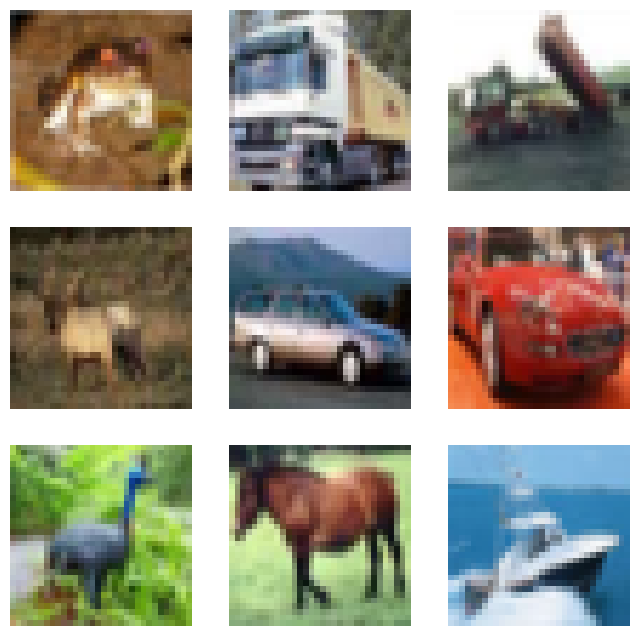

In [3]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.axis("off")

plt.show()

In [4]:
x_train = x_train.astype("float32") / 255.0

x_test = x_test.astype("float32") / 255.0

In [5]:
y_train = to_categorical(y_train,10)

y_test = to_categorical(y_test,10)

In [6]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

In [7]:
model = Sequential()

# First Convolution Block
model.add(Conv2D(32,(3,3),
                 activation='relu',
                 padding='same',
                 input_shape=(32,32,3)))

model.add(Conv2D(32,(3,3),
                 activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.25))


# Second Convolution Block
model.add(Conv2D(64,(3,3),
                 activation='relu',
                 padding='same'))

model.add(Conv2D(64,(3,3),
                 activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.25))


# Fully Connected Layers
model.add(Flatten())

model.add(Dense(512,
                activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(10,
                activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,250,858 (4.77 MB)

 Trainable params: 1,250,858 (4.77 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 136s 214ms/step - accuracy: 0.4111 - loss: 1.6083 - val_accuracy: 0.5630 - val_loss: 1.2329
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 132s 211ms/step - accuracy: 0.5671 - loss: 1.2069 - val_accuracy: 0.6258 - val_loss: 1.0689
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 132s 211ms/step - accuracy: 0.6356 - loss: 1.0308 - val_accuracy: 0.6886 - val_loss: 0.8996
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 136s 218ms/step - accuracy: 0.6755 - loss: 0.9259 - val_accuracy: 0.7030 - val_loss: 0.8461
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 135s 206ms/step - accuracy: 0.7043 - loss: 0.8439 - val_accuracy: 0.7152 - val_loss: 0.8103
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 203ms/step - accuracy: 0.7204 - loss: 0.7914 - val_accuracy: 0.7430 - val_loss: 0.7441
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 126s 201ms/step - accuracy: 0.7366 - loss: 0.7405 - val_accuracy: 0.7455 - val_loss: 0.7225
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 198ms/step - accuracy: 0.7490 -

In [11]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nTest Accuracy :", round(test_accuracy*100,2),"%")


Test Accuracy : 78.62 %


In [12]:
train_accuracy = history.history['accuracy'][-1]
validation_accuracy = history.history['val_accuracy'][-1]

print("Training Accuracy :", round(train_accuracy*100,2),"%")
print("Validation Accuracy :", round(validation_accuracy*100,2),"%")
print("Test Accuracy :", round(test_accuracy*100,2),"%")

Training Accuracy : 83.81 %
Validation Accuracy : 78.8 %
Test Accuracy : 78.62 %


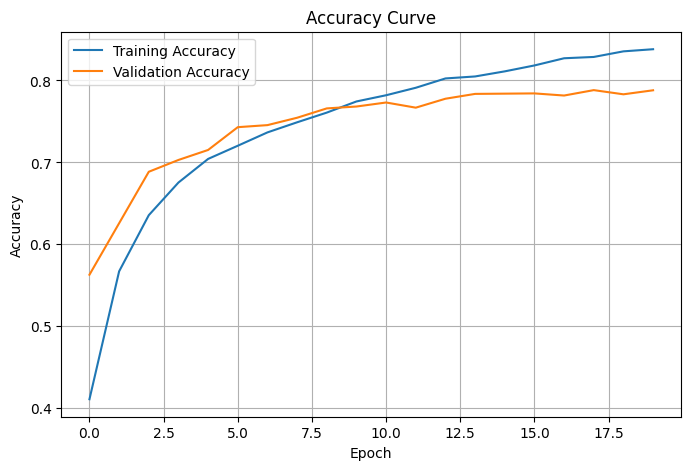

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title("Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

plt.show()

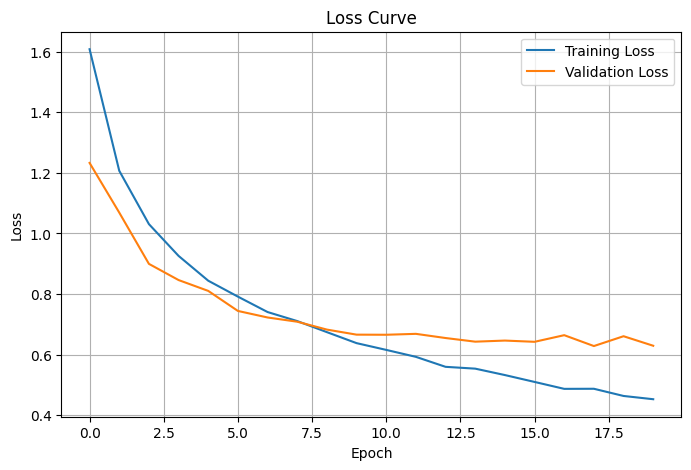

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title("Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

In [15]:
predictions = model.predict(x_test[:10])

predicted_classes = np.argmax(predictions,axis=1)

true_classes = np.argmax(y_test[:10],axis=1)

for i in range(10):
    print("--------------------------------")
    print("Image",i+1)
    print("Actual    :",class_names[true_classes[i]])
    print("Predicted :",class_names[predicted_classes[i]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
--------------------------------
Image 1
Actual    : Cat
Predicted : Cat
--------------------------------
Image 2
Actual    : Ship
Predicted : Ship
--------------------------------
Image 3
Actual    : Ship
Predicted : Ship
--------------------------------
Image 4
Actual    : Airplane
Predicted : Airplane
--------------------------------
Image 5
Actual    : Frog
Predicted : Frog
--------------------------------
Image 6
Actual    : Frog
Predicted : Frog
--------------------------------
Image 7
Actual    : Automobile
Predicted : Automobile
--------------------------------
Image 8
Actual    : Frog
Predicted : Deer
--------------------------------
Image 9
Actual    : Cat
Predicted : Cat
--------------------------------
Image 10
Actual    : Automobile
Predicted : Automobile


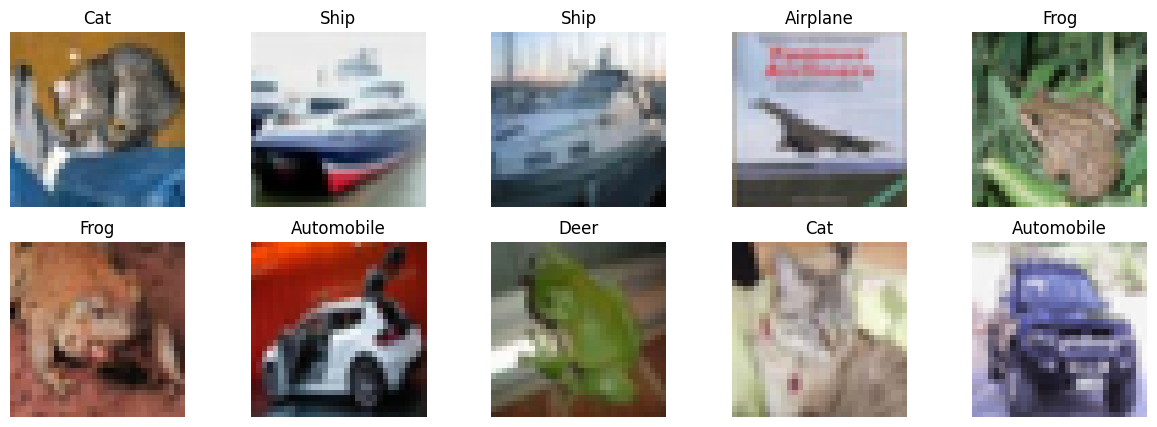

In [16]:
plt.figure(figsize=(15,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(x_test[i])

    plt.title(class_names[predicted_classes[i]])

    plt.axis("off")

plt.show()